# 🧬 Visor Rápido y Control de Calidad de Archivos FASTQ Comprimidos / Fast FASTQ.GZ Viewer & QC

### 🇪🇸 Instrucciones de Uso (Español)
Este cuaderno de Google Colab permite inspeccionar el formato y contenido de archivos de secuenciación `.fastq.gz` de forma ultraeficiente, leyendo directamente el archivo comprimido sin saturar la memoria RAM.

**Pasos para ejecutar el análisis:**
1. **Instalar dependencias:** Ejecuta la primera celda de código (`!pip install biopython`) para preparar el entorno.
2. **Subir el archivo:** Abre la barra lateral izquierda (icono de la carpeta 📂) y arrastra tu archivo `.fastq.gz`. Espera a que la barra de carga circular de abajo a la izquierda se complete.
3. **Ejecutar las celdas:** Ejecuta las celdas de análisis de texto y control de calidad visual. El script detectará automáticamente el archivo.

---

### 🇬🇧 User Guide (English)
This Google Colab notebook allows you to inspect the format and content of `.fastq.gz` sequencing files ultra-efficiently. It reads directly from the compressed file without overloading the RAM memory.

**Steps to run the analysis:**
1. **Install dependencies:** Run the first code cell (`!pip install biopython`) to set up the environment.
2. **Upload your file:** Open the left sidebar (folder icon 📂) and drag-and-drop your `.fastq.gz` file. Wait until the circular upload progress bar at the bottom-left is fully completed.
3. **Run the cells:** Execute both the text viewer and the visual quality control cells. The script will automatically detect your file.

In [14]:
# Instalar Biopython en el servidor de Google Colab
!pip install biopython

### 🇪🇸 1. Visor de Estructura de Lecturas (Texto plano)
Esta celda abrirá el archivo comprimido y extraerá las primeras lecturas de forma limpia para revisar las cabeceras (IDs) de Illumina, las secuencias y la conversión automática a scores Phred numéricos.

---

### 🇬🇧 1. Read Structure Viewer (Plain Text)
This cell will open the compressed file and extract the first few reads cleanly to review Illumina headers (IDs), sequences, and the automatic conversion to numerical Phred scores.

In [15]:
from Bio import SeqIO
import gzip
import os

# Buscamos cualquier archivo que termine en .fastq.gz que hayas subido
archivos_fastq = [f for f in os.listdir("/content") if f.endswith(".fastq.gz")]

if not archivos_fastq:
    print("❌ ERROR: No he encontrado ningún archivo .fastq.gz en la barra lateral.")
    print("Por favor, asegúrate de haberlo arrastrado correctamente.")
else:
    archivo_detectado = os.path.join("/content", archivos_fastq[0])
    print(f"✅ Archivo detectado con éxito: {archivo_detectado}\n")

    # Configuración: Cuántas lecturas espiar
    NUM_LECTURAS_A_MOSTRAR = 3

    with gzip.open(archivo_detectado, "rt") as archivo_descomprimido:
        lector_fastq = SeqIO.parse(archivo_descomprimido, "fastq")

        for contador, lectura in enumerate(lector_fastq):
            if contador >= NUM_LECTURAS_A_MOSTRAR:
                break

            print(f"=== LECTURA NÚMERO {contador + 1} ===")
            print(f"ID (Cabecera): @{lectura.description}")
            print(f"Secuencia: {lectura.seq}")
            print(f"Longitud: {len(lectura.seq)} bp")

            calidades_phred = lectura.letter_annotations["phred_quality"]
            print(f"Calidad (Primeros 15 Phred scores): {calidades_phred[:15]}")
            print("-" * 50 + "\n")

✅ Archivo detectado con éxito: /content/TW2_NA12878_1.fastq.gz

=== LECTURA NÚMERO 1 ===
ID (Cabecera): @LH00129:23:223NNNLT3:5:1143:13186:24392 1:N:0:ACACTGGCTA+TCCAAGCAGG
Secuencia: TTACATATTCAGAGAATACAGCCCAGTAGAGTTTATTGCCACCAAAGGTACGCCGCATGAAAAAGGCACCCGACATTCGTAGCAGCTCACCAACCATTTTCATTCCCAGGAAGTCTAAAAAAGAGGGAGATCGGAAGAGCACACGTCTGAA
Longitud: 151 bp
Calidad (Primeros 15 Phred scores): [37, 37, 37, 37, 37, 37, 37, 37, 37, 37, 37, 37, 37, 37, 37]
--------------------------------------------------

=== LECTURA NÚMERO 2 ===
ID (Cabecera): @LH00129:23:223NNNLT3:4:1101:32557:1048 1:N:0:ACACTGGCTA+TCCAAGCAGG
Secuencia: ANATTATTGTGCATTGAAGGGTTGTGGTCTCCTGAACAGAAGTCTGTCTCCAAACACAAATCAAGCAGCAAGATCATCTGCTGCAGGTAAGTGCAGCTCTGACGATAAGATTTATGTTCCTTCATCTTCCACACAGACTCTCAAAATCCAA
Longitud: 151 bp
Calidad (Primeros 15 Phred scores): [37, 2, 37, 37, 37, 37, 37, 37, 37, 37, 37, 37, 37, 37, 37]
--------------------------------------------------

=== LECTURA NÚMERO 3 ===
ID (Cabecera): @LH00129:23:223NNNLT3:

### 🇪🇸 2. Control de Calidad Visual (Submuestreo de 10k lecturas)
Esta sección analiza las primeras 10,000 lecturas del archivo para generar métricas de control de calidad visual instantáneas:
* **Gráfico de Calidad Phred:** Distribución de calidad media. Lo ideal es que la mayoría esté a la derecha de la línea roja (Q30), lo que indica un 99.9% de exactitud por base.
* **Gráfico de Contenido GC:** Porcentaje de Guaninas y Citosinas. Suele mostrar una campana de Gauss centrada entre el 40% y 50% según la especie.

---

### 🇬🇧 2. Visual Quality Control (10k Reads Subsampling)
This section analyzes the first 10,000 reads of the file to generate instant visual quality control metrics:
* **Phred Score Plot:** Average quality distribution. Ideally, most reads should be to the right of the red dashed line (Q30), indicating 99.9% base call accuracy.
* **GC Content Plot:** Percentage of Guanines and Cytosines. It typically displays a Gaussian bell curve centered between 40% and 50% depending on the species.

📊 Analizando el archivo para generar gráficos... Por favor, espera.


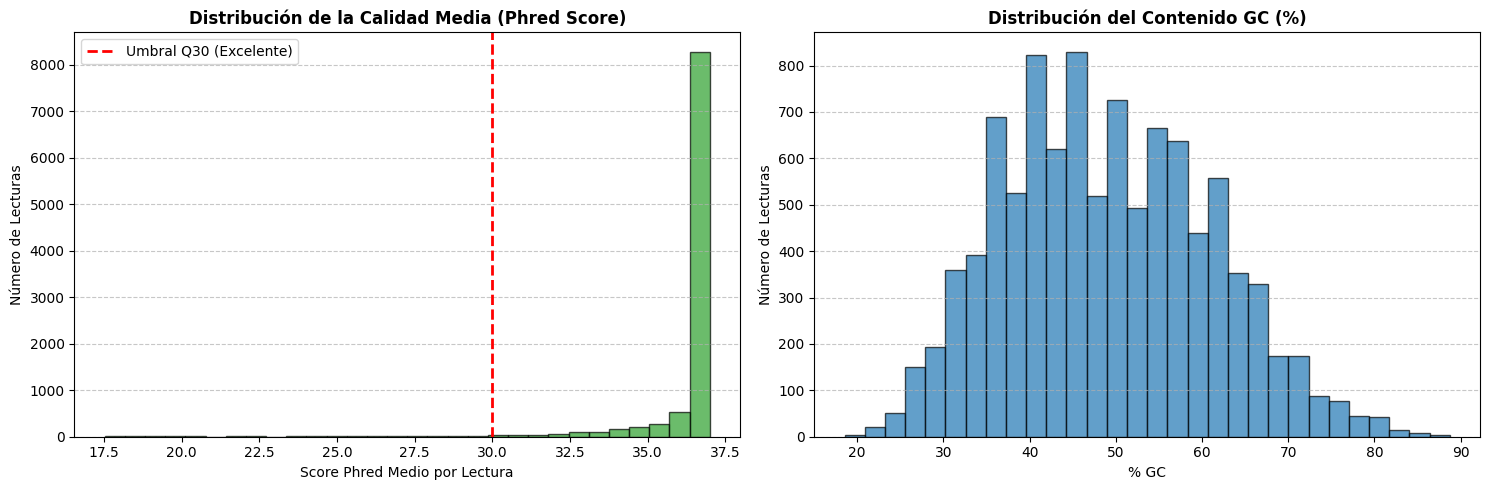


📈 Gráficos generados con éxito basados en las primeras 10000 lecturas.


In [16]:
from Bio import SeqIO
from Bio.SeqUtils import gc_fraction
import gzip
import os
import matplotlib.pyplot as plt

archivos_fastq = [f for f in os.listdir("/content") if f.endswith(".fastq.gz")]

if not archivos_fastq:
    print("❌ No se encontró el archivo .fastq.gz para el análisis visual.")
else:
    archivo_detectado = os.path.join("/content", archivos_fastq[0])
    print("📊 Analizando el archivo para generar gráficos... Por favor, espera.")

    lista_calidades_medias = []
    lista_porcentajes_gc = []
    MAX_LECTURAS_GRAFICO = 10000

    with gzip.open(archivo_detectado, "rt") as handle:
        for contador, lectura in enumerate(SeqIO.parse(handle, "fastq")):
            if contador >= MAX_LECTURAS_GRAFICO:
                break

            calidades = lectura.letter_annotations["phred_quality"]
            lista_calidades_medias.append(sum(calidades) / len(calidades))
            lista_porcentajes_gc.append(gc_fraction(lectura.seq) * 100)

    # Generar los gráficos con Matplotlib
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Histograma Phred
    ax1.hist(lista_calidades_medias, bins=30, color='#2ca02c', alpha=0.7, edgecolor='black')
    ax1.axvline(30, color='red', linestyle='dashed', linewidth=2, label='Umbral Q30 (Excelente)')
    ax1.set_title('Distribución de la Calidad Media (Phred Score)', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Score Phred Medio por Lectura')
    ax1.set_ylabel('Número de Lecturas')
    ax1.grid(axis='y', linestyle='--', alpha=0.7)
    ax1.legend()

    # Histograma GC
    ax2.hist(lista_porcentajes_gc, bins=30, color='#1f77b4', alpha=0.7, edgecolor='black')
    ax2.set_title('Distribución del Contenido GC (%)', fontsize=12, fontweight='bold')
    ax2.set_xlabel('% GC')
    ax2.set_ylabel('Número de Lecturas')
    ax2.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()
    print(f"\n📈 Gráficos generados con éxito basados en las primeras {contador} lecturas.")

* **Gráfico de Calidad por Posición (Estilo FastQC):** Muestra cómo varía la calidad a medida que el secuenciador avanza a lo largo de la lectura (de la base 1 a la final). La línea roja representa la mediana. Si la línea se mantiene en la zona verde, la carrera es excelente. Si cae a la zona amarilla o roja al final, indica que esas bases finales tienen menor fiabilidad.

---

* **Quality per Base Position Plot (FastQC Style):** Shows how quality changes as the sequencer moves along the read (from base 1 to the end). The red line represents the median score. If the line stays in the green zone, the run is excellent. If it drops into the yellow or red zones toward the end, it indicates that those final bases are less reliable.

📊 Analizando el archivo para generar el triple panel de gráficos... Por favor, espera.


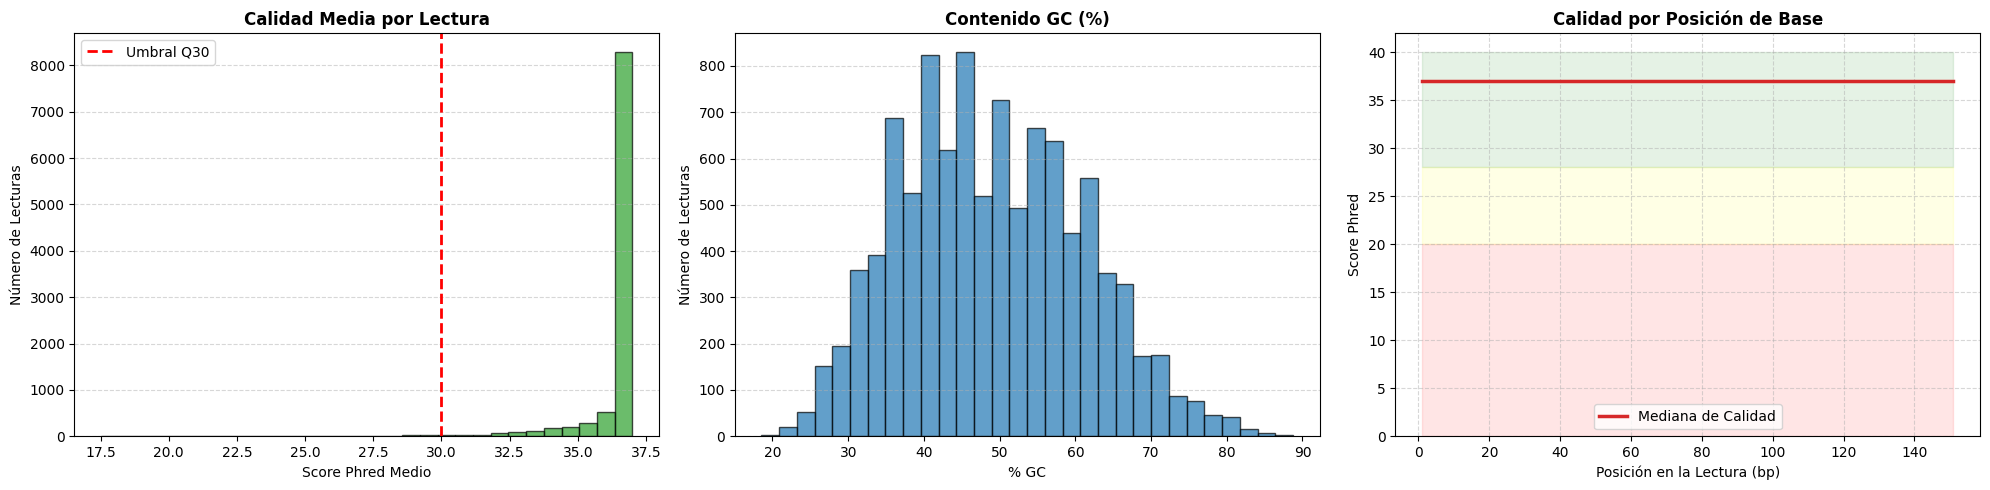


📈 ¡Triple panel de Control de Calidad generado con éxito!


In [17]:
from Bio import SeqIO
from Bio.SeqUtils import gc_fraction
import gzip
import os
import matplotlib.pyplot as plt
import numpy as np

archivos_fastq = [f for f in os.listdir("/content") if f.endswith(".fastq.gz")]

if not archivos_fastq:
    print("❌ No se encontró el archivo .fastq.gz para el análisis visual.")
else:
    archivo_detected = os.path.join("/content", archivos_fastq[0])
    print("📊 Analizando el archivo para generar el triple panel de gráficos... Por favor, espera.")

    lista_calidades_medias = []
    lista_porcentajes_gc = []

    # Para el gráfico base por base, necesitamos registrar las calidades en cada posición de la lectura
    # Analizamos primero la longitud máxima leyendo una única secuencia de prueba
    with gzip.open(archivo_detected, "rt") as test_handle:
        primera_lectura = next(SeqIO.parse(test_handle, "fastq"))
        longitud_lectura = len(primera_lectura.seq)

    # Creamos una matriz vacía para acumular las calidades por posición (Lecturas x Posición)
    MAX_LECTURAS_GRAFICO = 10000
    matriz_calidades = np.zeros((MAX_LECTURAS_GRAFICO, longitud_lectura))

    with gzip.open(archivo_detected, "rt") as handle:
        for contador, lectura in enumerate(SeqIO.parse(handle, "fastq")):
            if contador >= MAX_LECTURAS_GRAFICO:
                break

            calidades = lectura.letter_annotations["phred_quality"]
            lista_calidades_medias.append(sum(calidades) / len(calidades))
            lista_porcentajes_gc.append(gc_fraction(lectura.seq) * 100)

            # Guardamos las calidades de esta lectura en la fila correspondiente de la matriz
            # (Ajustamos por si alguna lectura fuera más corta por control de calidad previo)
            matriz_calidades[contador, :len(calidades)] = calidades

    # Recortamos la matriz al número real de lecturas procesadas si el archivo tuviera menos de 10k
    matriz_calidades = matriz_calidades[:contador, :]

    # Calculamos la mediana de calidad para cada una de las posiciones (columnas)
    calidad_por_posicion = np.median(matriz_calidades, axis=0)

    # =======================================================
    # 🎨 PARTE VISUAL: GENERAR EL TRIPLE PANEL
    # =======================================================
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 5))

    # Gráfico 1: Histograma Phred Medio
    ax1.hist(lista_calidades_medias, bins=30, color='#2ca02c', alpha=0.7, edgecolor='black')
    ax1.axvline(30, color='red', linestyle='dashed', linewidth=2, label='Umbral Q30')
    ax1.set_title('Calidad Media por Lectura', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Score Phred Medio')
    ax1.set_ylabel('Número de Lecturas')
    ax1.grid(axis='y', linestyle='--', alpha=0.5)
    ax1.legend()

    # Gráfico 2: Histograma Contenido GC
    ax2.hist(lista_porcentajes_gc, bins=30, color='#1f77b4', alpha=0.7, edgecolor='black')
    ax2.set_title('Contenido GC (%)', fontsize=12, fontweight='bold')
    ax2.set_xlabel('% GC')
    ax2.set_ylabel('Número de Lecturas')
    ax2.grid(axis='y', linestyle='--', alpha=0.5)

    # Gráfico 3: Calidad Base por Base (Estilo FastQC)
    ax3.plot(range(1, longitud_lectura + 1), calidad_por_posicion, color='#d62728', linewidth=2.5, label='Mediana de Calidad')
    # Pintamos zonas de calidad (Verde = Buena, Amarillo = Alerta, Rojo = Mala)
    ax3.fill_between(range(1, longitud_lectura + 1), 28, 40, color='green', alpha=0.1)
    ax3.fill_between(range(1, longitud_lectura + 1), 20, 28, color='yellow', alpha=0.1)
    ax3.fill_between(range(1, longitud_lectura + 1), 0, 20, color='red', alpha=0.1)

    ax3.set_title('Calidad por Posición de Base', fontsize=12, fontweight='bold')
    ax3.set_xlabel('Posición en la Lectura (bp)')
    ax3.set_ylabel('Score Phred')
    ax3.set_ylim(0, 42)
    ax3.grid(linestyle='--', alpha=0.5)
    ax3.legend()

    plt.tight_layout()
    plt.show()
    print(f"\n📈 ¡Triple panel de Control de Calidad generado con éxito!")